# COMM5501 Project Demo
## Fair Public EV Charging Access Across NSW (SDG 11)

**Topic Question:** *How can NSW transport and energy planners improve public EV charging access in outer-suburban areas so the shift to electric vehicles is geographically fair?*

**Target Audience:** NSW transport and energy planners / local councils responsible for charging-infrastructure rollout.

---

## 1. Dataset Source

All data comes from **raw, unmodified government open data** (CC-BY 4.0). Both files are kept in the project to ensure full reproducibility.

| # | Dataset | Publisher | What it provides | File in project | Accessed |
|---|---------|-----------|------------------|-----------------|----------|
| 1 | NSW EV charging station locations | Transport for NSW / NSW Govt (Data.NSW) | Every public charging site in NSW: operator, plug count, charger type, LGA | `ev_20251216.csv` | 16 Dec 2025 |
| 2 | Regional population, 2024-25 (Population estimates and components by LGA) | Australian Bureau of Statistics (ABS), cat. 3218.0 | Estimated resident population (ERP) for all 129 NSW LGAs at 30 June 2025 | `data/abs_regional_population_lga_2024_25.xlsx` | 24 Jun 2026 |
| 3 | Greater Sydney GCCSA boundary (LGA list) | ABS ASGS Edition 3 | Which LGAs make up "Greater Sydney" | encoded in code below | 24 Jun 2026 |

**Source links**
- NSW EV charging stations: <https://data.nsw.gov.au/data/dataset/electric-vehicle-charging-points>
- ABS Regional population 2024-25: <https://www.abs.gov.au/statistics/people/population/regional-population/latest-release>
- ABS ASGS GCCSA (Greater Sydney): <https://www.abs.gov.au/statistics/standards/australian-statistical-geography-standard-asgs-edition-3/jul2021-jun2026>

### Why these datasets?

- **Reputable & authoritative:** Both datasets come from official Australian government sources (Transport for NSW and ABS), ensuring credibility for the target audience of policy planners.
- **Complete coverage:** The charging dataset covers every public charging site in NSW; the ABS population data covers all 129 NSW LGAs.
- **Complementary:** Combining charging supply data with population data enables a **per-capita fairness metric** — the key to answering our topic question.

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

OUT = Path("outputs")
OUT.mkdir(exist_ok=True)

INK = "#1a1a2e"
MUTED = "#c7ccd6"
ACCENT = "#e63946"
INNER = "#2a6f97"

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "font.size": 11,
    "axes.titlesize": 13,
    "font.family": "DejaVu Sans",
})

print("Libraries loaded. matplotlib", plt.matplotlib.__version__,
      "| pandas", pd.__version__)

Libraries loaded. matplotlib 3.11.0 | pandas 3.0.3


In [2]:
# ---- Data loading and cleaning ----
GREATER_SYDNEY_RAW = [
    "Bayside", "Blacktown", "Blue Mountains", "Burwood", "Camden",
    "Campbelltown", "Canada Bay", "Canterbury-Bankstown", "Central Coast",
    "Cumberland", "Fairfield", "Georges River", "Hawkesbury", "Hornsby",
    "Hunters Hill", "Inner West", "Ku-ring-gai", "Lane Cove", "Liverpool",
    "Mosman", "North Sydney", "Northern Beaches", "Parramatta", "Penrith",
    "Randwick", "Ryde", "Strathfield", "Sutherland Shire", "Sydney",
    "The Hills Shire", "Waverley", "Willoughby", "Wollondilly", "Woollahra",
]

_DROP_TOKENS = {
    "council", "city", "shire", "municipality", "municipal", "regional",
    "district", "of", "the", "area", "nsw", "vic", "tas", "qld",
}


def norm_lga(name: str) -> str:
    """Normalise an LGA label so the CSV and ABS spellings match."""
    if not isinstance(name, str):
        return ""
    s = name.lower().strip().replace("&", "and")
    s = re.sub(r"\(.*?\)", " ", s)
    s = s.split(",")[0]
    s = s.replace("-", " ")
    s = re.sub(r"[^a-z\s]", " ", s)
    tokens = [t for t in s.split() if t and t not in _DROP_TOKENS]
    return " ".join(tokens).strip()


GREATER_SYDNEY = {norm_lga(x) for x in GREATER_SYDNEY_RAW}

ev = pd.read_csv("ev_20251216.csv")
ev["plugs"] = pd.to_numeric(ev["Number_of_plugs"], errors="coerce")
ev = ev.dropna(subset=["LGANAME"]).copy()
ev["lga_key"] = ev["LGANAME"].map(norm_lga)

abs_raw = pd.read_excel(
    "data/abs_regional_population_lga_2024_25.xlsx",
    sheet_name="Table 1", header=None,
)
pop_rows = []
for _, r in abs_raw.iterrows():
    code = r[0]
    if isinstance(code, (int, float)) and not pd.isna(code) and code >= 10000:
        if isinstance(r[1], str) and pd.notna(r[3]):
            pop_rows.append((int(code), r[1].strip(), float(r[3])))
pop = pd.DataFrame(pop_rows, columns=["lga_code", "lga_name", "erp_2025"])
pop["lga_key"] = pop["lga_name"].map(norm_lga)

by_lga = (ev.groupby("lga_key")
            .agg(sites=("plugs", "size"), plugs=("plugs", "sum"))
            .reset_index())
check = by_lga.merge(pop, on="lga_key", how="left", indicator=True)
matched = check.loc[check["_merge"] == "both", "plugs"].sum()

print(f"Charging sites: {len(ev):,}  |  total public plugs: {ev['plugs'].sum():,.0f}")
print(f"NSW LGAs in ABS: {len(pop)}  |  Greater Sydney LGAs identified: {len(GREATER_SYDNEY)}")
print(f"Charging LGAs matched to ABS population: "
      f"{(check['_merge']=='both').sum()} / {len(check)}")
print(f"Plugs successfully joined: {matched:,.0f} "
      f"({matched/ev['plugs'].sum()*100:.1f}% of all plugs)")

Charging sites: 1,837  |  total public plugs: 5,010
NSW LGAs in ABS: 129  |  Greater Sydney LGAs identified: 34
Charging LGAs matched to ABS population: 125 / 125
Plugs successfully joined: 5,010 (100.0% of all plugs)


In [3]:
# ---- Build the access metric ----
full = pop.merge(by_lga, on="lga_key", how="left")
full[["plugs", "sites"]] = full[["plugs", "sites"]].fillna(0)
full["region"] = np.where(full["lga_key"].isin(GREATER_SYDNEY),
                          "Greater Sydney", "Rest of NSW")
full["plugs_per_10k"] = full["plugs"] / full["erp_2025"] * 10_000

region = (full.groupby("region")
              .apply(lambda d: pd.Series({
                  "lgas": len(d),
                  "population": d["erp_2025"].sum(),
                  "plugs": d["plugs"].sum(),
                  "plugs_per_10k": d["plugs"].sum() / d["erp_2025"].sum() * 10_000,
              }), include_groups=False))
print("Region aggregate (population-weighted):")
print(region.round(2).to_string())

gs = full[full["region"] == "Greater Sydney"].sort_values("plugs_per_10k")
half = len(gs) // 2
bottom, top = gs.head(half), gs.tail(half)
ratio = (top["plugs"].sum()/top["erp_2025"].sum()) / (bottom["plugs"].sum()/bottom["erp_2025"].sum())
print(f"\nWithin Greater Sydney (34 LGAs):")
print(f"  Best served : {gs.iloc[-1]['lga_name']} = {gs.iloc[-1]['plugs_per_10k']:.1f} plugs/10k")
print(f"  Worst served: {gs.iloc[0]['lga_name']} = {gs.iloc[0]['plugs_per_10k']:.1f} plugs/10k")
print(f"  Better-served half has ~{ratio:.1f}x the plugs per resident of the worse-served half.")

Region aggregate (population-weighted):
                lgas  population   plugs  plugs_per_10k
region                                                 
Greater Sydney  34.0   5638647.0  2280.0           4.04
Rest of NSW     95.0   2953877.0  2730.0           9.24

Within Greater Sydney (34 LGAs):
  Best served : Woollahra = 16.5 plugs/10k
  Worst served: Cumberland = 0.7 plugs/10k
  Better-served half has ~3.9x the plugs per resident of the worse-served half.


---

## 2. The Graph

The chart compares the **10 most under-served** and **5 best-served** Greater Sydney LGAs by public EV charging plugs per 10,000 residents — making the equity gap immediately visible.

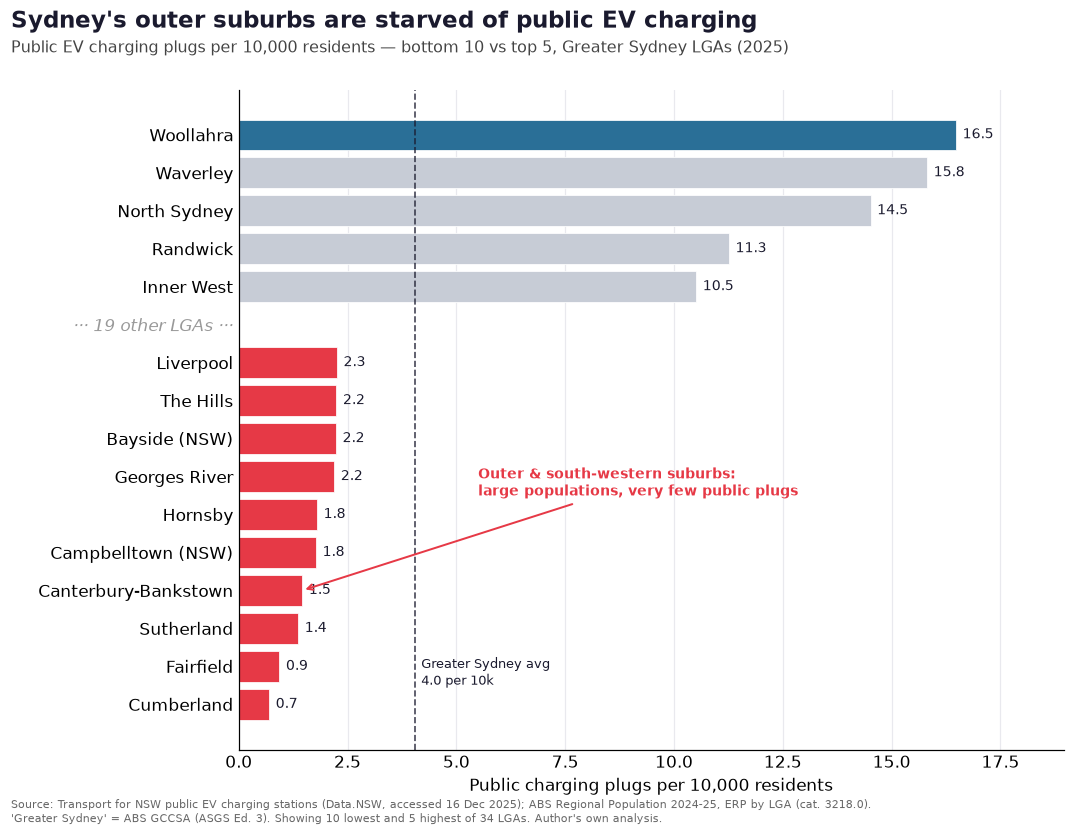

Saved -> outputs/demo_sydney_charging_equity.png


In [4]:
# ---- FINAL HERO CHART (Bottom 10 + Top 5 with visual gap) ----
gs_all = full[full["region"] == "Greater Sydney"].sort_values(
    "plugs_per_10k", ascending=True).reset_index(drop=True)
metro_avg = gs_all["plugs"].sum() / gs_all["erp_2025"].sum() * 10_000

N_BOTTOM, N_TOP = 10, 5
bottom = gs_all.head(N_BOTTOM).copy()
top = gs_all.tail(N_TOP).copy()

GAP_LABEL = f"··· {len(gs_all) - N_BOTTOM - N_TOP} other LGAs ···"
gap_row = pd.DataFrame([{
    "lga_name": GAP_LABEL,
    "plugs_per_10k": 0,
    "plugs": 0,
    "erp_2025": 0,
}])
gs_chart = pd.concat([bottom, gap_row, top], ignore_index=True)

colours = []
for i, row in gs_chart.iterrows():
    if row["lga_name"] == GAP_LABEL:
        colours.append("none")
    elif row["plugs_per_10k"] < metro_avg:
        colours.append(ACCENT)
    elif i == len(gs_chart) - 1:
        colours.append(INNER)
    else:
        colours.append(MUTED)

fig, ax = plt.subplots(figsize=(10, 7.5))
y_positions = list(range(len(gs_chart)))
bars = ax.barh(y_positions, gs_chart["plugs_per_10k"],
               color=colours, edgecolor="white", linewidth=0.5)

for y, (_, row) in zip(y_positions, gs_chart.iterrows()):
    if row["lga_name"] != GAP_LABEL:
        ax.text(row["plugs_per_10k"] + 0.15, y, f"{row['plugs_per_10k']:.1f}",
                va="center", ha="left", fontsize=9, color=INK)

ax.set_yticks(y_positions)
ax.set_yticklabels(gs_chart["lga_name"])
gap_idx = N_BOTTOM
ax.get_yticklabels()[gap_idx].set_fontstyle("italic")
ax.get_yticklabels()[gap_idx].set_color("#999")

ax.axvline(metro_avg, color=INK, linewidth=1.1, linestyle="--", alpha=0.8)
ax.text(metro_avg + 0.15, 0.4, f"Greater Sydney avg\n{metro_avg:.1f} per 10k",
        fontsize=8.5, color=INK, va="bottom")

ax.set_title("")
fig.text(0.013, 0.975,
         "Sydney's outer suburbs are starved of public EV charging",
         fontsize=15, fontweight="bold", color=INK, ha="left")
fig.text(0.013, 0.945,
         "Public EV charging plugs per 10,000 residents — bottom 10 vs top 5, Greater Sydney LGAs (2025)",
         fontsize=10.5, color="#444", ha="left")

ax.annotate(
    "Outer & south-western suburbs:\nlarge populations, very few public plugs",
    xy=(gs_chart["plugs_per_10k"].iloc[3], 3),
    xytext=(5.5, 5.5), fontsize=9, color=ACCENT, fontweight="bold",
    arrowprops=dict(arrowstyle="->", color=ACCENT, lw=1.3))

ax.set_xlabel("Public charging plugs per 10,000 residents")
ax.set_xlim(0, gs_chart["plugs_per_10k"].max() * 1.15)
ax.spines[["top", "right"]].set_visible(False)
ax.xaxis.grid(True, color="#e9e9ee", linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(length=0)

fig.text(0.013, 0.012,
         "Source: Transport for NSW public EV charging stations (Data.NSW, accessed 16 Dec 2025); "
         "ABS Regional Population 2024-25, ERP by LGA (cat. 3218.0).\n"
         "'Greater Sydney' = ABS GCCSA (ASGS Ed. 3). Showing 10 lowest and 5 highest of 34 LGAs. "
         "Author's own analysis.",
         fontsize=7.5, color="#666", ha="left")

plt.subplots_adjust(top=0.90, bottom=0.10, left=0.22, right=0.97)
fig.savefig(OUT / "demo_sydney_charging_equity.png")
plt.show()
print("Saved -> outputs/demo_sydney_charging_equity.png")

---

## 3. Why This Graph?

### 3.1 Background Knowledge

- **SDG 11 — Sustainable Cities and Communities:** The UN Sustainable Development Goal 11 calls for making cities inclusive, safe, resilient and sustainable. Fair access to EV charging infrastructure is a key enabler of the transition to electric vehicles, which also connects to SDG 13 (Climate Action) and SDG 7 (Affordable & Clean Energy).

- **The EV transition challenge in NSW:** As EV adoption accelerates in NSW, public charging infrastructure must grow alongside it. However, not all communities benefit equally — residents in outer-suburban LGAs (e.g. Cumberland, Fairfield, Canterbury-Bankstown) often live in higher-density housing without private garages, making them *more* dependent on public charging, yet they are the most under-served.

- **Key finding from the data:** Greater Sydney as a whole has only **4.0 plugs per 10,000 residents** (vs 9.2 in Rest of NSW). The worst-served LGA (Cumberland, 0.7 plugs/10k) has over **20x less** access than the best-served (Woollahra, 16.5 plugs/10k).

### 3.2 Purpose of the Graph

The graph is designed to let a **planner quickly identify where public charging access per resident is lowest**, so investment can be directed to the areas that need it most.

Specifically, the graph supports this **Call to Action:**

> *NSW transport and energy planners should prioritise public EV charging rollout in under-served, high-population outer-suburban LGAs, rather than letting infrastructure concentrate in already well-served inner-city areas.*

### 3.3 Why the Graph Aligns with the Purpose

| Design Element | How it serves the purpose |
|----------------|---------------------------|
| **Bottom 10 vs Top 5 selection** | Reduces 34 LGAs to 15, focusing the viewer's attention on the extremes where the equity gap is most dramatic — avoids information overload while still covering all 34 in the analysis |
| **Per-capita metric** (plugs per 10,000 residents) | Enables fair comparison regardless of LGA population size — a raw plug count would falsely rank large LGAs as "well-served" |
| **Focused on Greater Sydney** | Controls for the tourist/highway-charger confounder. Compares like-for-like urban populations where the Call to Action applies |
| **Red highlight for under-served suburbs** | Colour is used *purposefully* — red only for LGAs below the metro average, drawing the planner's eye to where action is needed |
| **Metro-average reference line** | Provides an objective benchmark: the planner can instantly see whether their LGA is above or below average |
| **Visual gap** ("··· 19 other LGAs ···") | Honestly signals that middle LGAs exist but are omitted for clarity — transparent, not cherry-picked |
| **Takeaway title** | States the key message up front — the chart is an *argument*, not a neutral data dump |
| **Direct value labels + annotation arrow** | Each bar shows its exact number; the arrow reinforces the story at the worst-served cluster |

### Summary

The graph transforms raw government open data into a **decision-ready argument**:
- It uses a **fair per-capita metric** to reveal hidden inequality;
- It **focuses on the extremes** (bottom 10 vs top 5) to maximise clarity without losing integrity;
- It employs **purposeful design** (colour, sorting, annotation, reference line) to guide the target audience directly to the actionable insight.

A planner viewing this chart can immediately see that the outer and south-western suburbs are the most under-served for public EV charging, and thus should be prioritised for infrastructure investment.

---

## References

1. Transport for NSW / NSW Government. *Electric vehicle charging stations (NSW)*. Data.NSW. Licensed CC-BY 4.0. <https://data.nsw.gov.au/data/dataset/electric-vehicle-charging-points> (data file `ev_20251216.csv`, accessed 16 Dec 2025).
2. Australian Bureau of Statistics. *Regional population, 2024-25 financial year* (cat. 3218.0), data cube *Population estimates and components by LGA* (`32180DS0002_2024-25.xlsx`). Licensed CC-BY 4.0. <https://www.abs.gov.au/statistics/people/population/regional-population/latest-release> (accessed 24 Jun 2026).
3. Australian Bureau of Statistics. *Australian Statistical Geography Standard (ASGS) Edition 3, Greater Capital City Statistical Areas (Greater Sydney)*. <https://www.abs.gov.au/statistics/standards/australian-statistical-geography-standard-asgs-edition-3/jul2021-jun2026> (accessed 24 Jun 2026).
4. NSW Government. *NSW Electric Vehicle Strategy*. <https://www.energy.nsw.gov.au/business-and-industry/programs-grants-and-schemes/electric-vehicles> (accessed 16 Dec 2025).